In [2]:
import os
import numpy as np
import pandas as pd
import random
from tqdm import tqdm

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler

In [3]:
from kaggle_secrets import UserSecretsClient
secret_label = "wandb_api_key"
wandb_key = UserSecretsClient().get_secret(secret_label)

In [4]:
import wandb

wandb.login(key=wandb_key)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: suranjan-das to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Prepare data

### Build a metadata dataframe

In [5]:
dataset_root = "/kaggle/input/datasets/suranjandas1990/forest-loss-dataset/dataset"

records = []

regions = ["Meghalaya_2021_2023", "Nagaland_2021_2023"]

for region in regions:

    label_dir = os.path.join(dataset_root, region, "label")

    for fname in tqdm(os.listdir(label_dir)):

        path = os.path.join(label_dir, fname)

        mask = np.load(path)

        change_pixels = mask.sum()
        total_pixels = mask.size

        change_ratio = change_pixels / total_pixels

        records.append({
            "region": region,
            "file": fname,
            "label_path": path,
            "change_pixels": change_pixels,
            "change_ratio": change_ratio
        })

df = pd.DataFrame(records)

100%|██████████| 2431/2431 [00:12<00:00, 200.80it/s]


In [6]:
print("Total samples:", len(df))
df.head()

Total samples: 5778


,region,file,label_path,change_pixels,change_ratio
0,Meghalaya_2021_2023,Siamese_Tiles-0000003328-0000010496.npy,/kaggle/input/datasets/suranjandas1990/forest-...,364.0,0.005554
1,Meghalaya_2021_2023,Siamese_Tiles-0000009216-0000024832.npy,/kaggle/input/datasets/suranjandas1990/forest-...,238.0,0.003632
2,Meghalaya_2021_2023,Siamese_Tiles-0000005376-0000007424.npy,/kaggle/input/datasets/suranjandas1990/forest-...,76.0,0.001160
3,Meghalaya_2021_2023,Siamese_Tiles-0000008704-0000016640.npy,/kaggle/input/datasets/suranjandas1990/forest-...,0.0,0.000000
4,Meghalaya_2021_2023,Siamese_Tiles-0000009984-0000014080.npy,/kaggle/input/datasets/suranjandas1990/forest-...,239.0,0.003647


### Create stratification bins

In [7]:
bins = [0, 1e-6, 0.005, 0.02, 1]
labels = [
    "no_change",
    "very_sparse",
    "sparse",
    "moderate_large"
]

df["change_bin"] = pd.cut(
    df["change_ratio"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df["stratify_key"] = df["region"] + "_" + df["change_bin"].astype(str)

In [8]:
df.sample(5)['stratify_key']

1921         Meghalaya_2021_2023_sparse
985     Meghalaya_2021_2023_very_sparse
1450         Meghalaya_2021_2023_sparse
2332         Meghalaya_2021_2023_sparse
1133         Meghalaya_2021_2023_sparse
Name: stratify_key, dtype: object

In [9]:
df["change_bin"].value_counts() / len(df)

change_bin
very_sparse       0.356006
sparse            0.347871
moderate_large    0.184493
no_change         0.111630
Name: count, dtype: float64

### Stratified train / val / test split

In [10]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["stratify_key"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["stratify_key"],
    random_state=42
)

print(len(train_df), len(val_df), len(test_df))

4044 867 867


### Save the splits

In [11]:
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

In [12]:
# # code to calculate train data mean and std
# train_df = pd.read_csv("/kaggle/working/train_split.csv")
# root_dir = "/kaggle/input/datasets/suranjandas1990/forest-loss-dataset/dataset"

# sum_c = torch.zeros(6)
# sum_sq_c = torch.zeros(6)
# num_pixels = 0

# for _, row in tqdm(train_df.iterrows(), total=len(train_df)):

#     region = row["region"]
#     fname = row["file"]

#     t1 = np.load(f"{root_dir}/{region}/t1/{fname}", mmap_mode="r")
#     t2 = np.load(f"{root_dir}/{region}/t2/{fname}", mmap_mode="r")

#     t1 = torch.tensor(t1, dtype=torch.float32)
#     t2 = torch.tensor(t2, dtype=torch.float32)

#     img = torch.cat([t1, t2], dim=0)  # shape (12, H, W)

#     sum_c += img.sum(dim=[1,2])[:6] + img.sum(dim=[1,2])[6:]
#     sum_sq_c += (img**2).sum(dim=[1,2])[:6] + (img**2).sum(dim=[1,2])[6:]

#     num_pixels += 2 * img.shape[1] * img.shape[2]

# mean = sum_c / num_pixels
# std = torch.sqrt(sum_sq_c / num_pixels - mean**2)

# print("Mean:", mean.tolist())
# print("Std:", std.tolist())

### Dataset and Dataloader

In [13]:
data_mean = torch.tensor([0.0187, 0.0389, 0.0231, 0.2954, -8.4814, -14.8727]).view(6,1,1)
data_std = torch.tensor([0.0137, 0.0186, 0.0188, 0.0970, 2.2510, 2.2649]).view(6,1,1)

In [14]:
import torch
from torch.utils.data import Dataset
import numpy as np

class ChangeDataset(Dataset):

    def __init__(self, dataframe, root_dir, mean=data_mean, std=data_std):

        self.df = dataframe.reset_index(drop=True)
        self.root = root_dir

        # dataset mean/std (replace with values computed from your dataset)
        self.mean = mean
        self.std  = std

    def __len__(self):
        return len(self.df)

    def normalize(self, x):
        return (x - self.mean) / (self.std + 1e-6)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        region = row["region"]
        fname = row["file"]

        t1 = np.load(f"{self.root}/{region}/t1/{fname}", mmap_mode="r")
        t2 = np.load(f"{self.root}/{region}/t2/{fname}", mmap_mode="r")
        label = np.load(f"{self.root}/{region}/label/{fname}")

        t1 = torch.tensor(t1, dtype=torch.float32)
        t2 = torch.tensor(t2, dtype=torch.float32)

        t1 = self.normalize(t1)
        t2 = self.normalize(t2)

        label = torch.tensor(label, dtype=torch.float32).unsqueeze(0)

        return t1, t2, label

In [15]:
train_df = pd.read_csv("/kaggle/working/train_split.csv")
val_df = pd.read_csv("/kaggle/working/val_split.csv")

root_dir = "/kaggle/input/datasets/suranjandas1990/forest-loss-dataset/dataset"

train_dataset = ChangeDataset(train_df, root_dir)
val_dataset = ChangeDataset(val_df, root_dir)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                          num_workers=4, pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False,
                        num_workers=4, pin_memory=True)

## Model Build and Training

In [16]:
t1, t2, label = train_dataset[0]
t1.shape, t2.shape, label.shape

(torch.Size([6, 256, 256]),
 torch.Size([6, 256, 256]),
 torch.Size([1, 256, 256]))

In [17]:
class DoubleConv(nn.Module):

    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [18]:
class ASPP(nn.Module):

    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.conv1 = nn.Conv2d(in_ch, out_ch, 1)

        self.conv2 = nn.Conv2d(in_ch, out_ch, 3, padding=6, dilation=6)
        self.conv3 = nn.Conv2d(in_ch, out_ch, 3, padding=12, dilation=12)
        self.conv4 = nn.Conv2d(in_ch, out_ch, 3, padding=18, dilation=18)

        self.project = nn.Conv2d(out_ch * 4, out_ch, 1)

    def forward(self, x):

        f1 = self.conv1(x)
        f2 = self.conv2(x)
        f3 = self.conv3(x)
        f4 = self.conv4(x)

        x = torch.cat([f1, f2, f3, f4], dim=1)

        return self.project(x)

In [19]:
class Encoder(nn.Module):

    def __init__(self, in_channels=6):
        super().__init__()

        self.conv1 = DoubleConv(in_channels, 64)
        self.conv2 = DoubleConv(64, 128)
        self.conv3 = DoubleConv(128, 256)
        self.conv4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

    def forward(self, x):

        f1 = self.conv1(x)
        p1 = self.pool(f1)

        f2 = self.conv2(p1)
        p2 = self.pool(f2)

        f3 = self.conv3(p2)
        p3 = self.pool(f3)

        f4 = self.conv4(p3)
        p4 = self.pool(f4)

        return [f1, f2, f3, f4], p4

In [20]:
class UpBlock(nn.Module):

    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()

        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)

        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):

        x = self.up(x)

        x = torch.cat([x, skip], dim=1)

        return self.conv(x)

In [21]:
class SiameseUNet_ASPP(nn.Module):

    def __init__(self, in_channels=6):
        super().__init__()

        self.encoder = Encoder(in_channels)

        self.aspp = ASPP(512, 512)

        self.up4 = UpBlock(512, 1024, 512)
        self.up3 = UpBlock(512, 512, 256)
        self.up2 = UpBlock(256, 256, 128)
        self.up1 = UpBlock(128, 128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, t1, t2):

        feat1, bottleneck1 = self.encoder(t1)
        feat2, bottleneck2 = self.encoder(t2)

        x = torch.abs(bottleneck1 - bottleneck2)

        x = self.aspp(x)

        s4 = torch.cat([feat1[3], feat2[3]], dim=1)
        s3 = torch.cat([feat1[2], feat2[2]], dim=1)
        s2 = torch.cat([feat1[1], feat2[1]], dim=1)
        s1 = torch.cat([feat1[0], feat2[0]], dim=1)

        x = self.up4(x, s4)
        x = self.up3(x, s3)
        x = self.up2(x, s2)
        x = self.up1(x, s1)

        out = self.final(x)

        return out

In [22]:
class DiceLoss(nn.Module):

    def forward(self, pred, target):

        pred = torch.sigmoid(pred)

        smooth = 1e-6

        intersection = (pred * target).sum()

        union = pred.sum() + target.sum()

        dice = (2 * intersection + smooth) / (union + smooth)

        return 1 - dice

In [23]:
bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([20]).cuda())
dice = DiceLoss()

def loss_fn(pred, target):
    return 0.4*bce(pred,target) + 0.6*dice(pred,target)

In [24]:
def compute_metrics(pred, target):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.6).float()

    tp = (pred * target).sum()
    fp = (pred * (1-target)).sum()
    fn = ((1-pred) * target).sum()

    precision = tp/(tp+fp+1e-6)
    recall = tp/(tp+fn+1e-6)

    f1 = 2*precision*recall/(precision+recall+1e-6)

    iou = tp/(tp+fp+fn+1e-6)

    return f1.item(), iou.item()

### Training Loop

In [25]:
device = "cuda"

model = SiameseUNet_ASPP()

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model = torch.nn.DataParallel(model)

model = model.cuda()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Using 2 GPUs


In [26]:
model

DataParallel(
  (module): SiameseUNet_ASPP(
    (encoder): Encoder(
      (conv1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(6, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): ReLU(inplace=True)
        )
      )
      (conv2): DoubleConv(
        (block): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stat

In [27]:
wandb.init(
    project="forest-change-detection",
    name="unet_aspp_dice_bce(threshold=0.6)",
    config={
        "model": "UNet_ASPP",
        "loss": "0.4*Dice+0.6*BCE",
        "lr": 1e-4,
        "batch_size": 16,
        "epochs": 50
    }
)

In [28]:
# wandb.watch(model, log="all", log_freq=100)

In [29]:
best_iou = 0
patience = 5
epochs_without_improvement = 0

scaler = GradScaler(device="cuda")

for epoch in range(50):

    model.train()
    train_loss = 0

    for t1, t2, label in tqdm(train_loader):

        t1 = t1.to(device)
        t2 = t2.to(device)
        label = label.to(device)

        optimizer.zero_grad()

        with autocast(device_type="cuda"):
            pred = model(t1, t2)
            loss = loss_fn(pred, label)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)
    print("Train loss:", train_loss)

    model.eval()

    f1_scores = []
    ious = []

    with torch.no_grad():

        for t1, t2, label in val_loader:

            t1 = t1.to(device)
            t2 = t2.to(device)
            label = label.to(device)

            with autocast(device_type="cuda"):
                pred = model(t1, t2)

            f1, iou = compute_metrics(pred, label)

            f1_scores.append(f1)
            ious.append(iou)

    val_f1 = np.mean(f1_scores)
    val_iou = np.mean(ious)

    print("Val F1:", val_f1)
    print("Val IoU:", val_iou)

    # Log metrics
    wandb.log({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_f1": val_f1,
        "val_iou": val_iou
    })

    # Save best model
    if val_iou > best_iou:

        best_iou = val_iou
        epochs_without_improvement = 0

        torch.save(model.state_dict(), "best_model.pth")

        artifact = wandb.Artifact(
            name="siamese_unet_model",
            type="model"
        )

        artifact.add_file("best_model.pth")
        wandb.log_artifact(artifact)

        print("Saved new best model")

    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epochs")

    # Early stopping
    if epochs_without_improvement >= patience:
        print("Early stopping triggered")
        break

wandb.finish()

100%|██████████| 253/253 [01:39<00:00,  2.53it/s]

Train loss: 0.7533544973422416


Val F1: 0.35018431165001607
Val IoU: 0.21358327621763404
Saved new best model


100%|██████████| 253/253 [01:41<00:00,  2.50it/s]

Train loss: 0.6705708974906107


...

Val F1: 0.49109680977734654
Val IoU: 0.3277431983839382
No improvement for 4 epochs


100%|██████████| 253/253 [01:42<00:00,  2.47it/s]

Train loss: 0.3517057813203382


Val F1: 0.49918642965230076
Val IoU: 0.33479404178532685
No improvement for 5 epochs
Early stopping triggered


epoch,▁▁▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇██
train_loss,█▇▆▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁
val_f1,▁▂▃▁▄▅▇▄▇▇▇████▇█▇█
val_iou,▁▂▃▁▄▅▇▄▆▇▇███▇▇█▇█
epoch,18
train_loss,0.35171
val_f1,0.49919
val_iou,0.33479


#### Color	Meaning
Set $NIR=True$ to see false color
- Bright red: Healthy vegetation
- Dark brown: Bare soil / cleared land
- Gray: Urban
- Black: Water

In [43]:
def stretch(img):

    p2, p98 = np.percentile(img, (2, 98))
    img = np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)

    return img


def visualize_sample(t1, t2, pred, label, NIR=True, thresholds=[0.3, 0.5, 0.7]):

    t1 = t1.cpu().numpy()
    t2 = t2.cpu().numpy()
    pred = [p.cpu().numpy() for p in pred]
    label = label.cpu().numpy()

    if NIR:
        # False color: NIR-Red-Green
        fc1 = np.stack([t1[3], t1[2], t1[1]], axis=-1)
        fc2 = np.stack([t2[3], t2[2], t2[1]], axis=-1)
    else:
        fc1 = np.stack([t1[2], t1[1], t1[0]], axis=-1)
        fc2 = np.stack([t2[2], t2[1], t2[0]], axis=-1)

    fc1 = stretch(fc1)
    fc2 = stretch(fc2)

    fig, ax = plt.subplots(1,6, figsize=(14,4))

    ax[0].imshow(fc1)
    ax[0].set_title("T1 False Color (NIR-R-G)" if NIR else "T1 (RGB)")
    ax[0].axis("off")

    ax[1].imshow(fc2)
    ax[1].set_title("T2 False Color (NIR-R-G)" if NIR else "T2 (RGB)")
    ax[1].axis("off")

    ax[2].imshow(label, cmap="gray")
    ax[2].set_title("Ground Truth")
    ax[2].axis("off")

    ax[3].imshow(pred[0], cmap="gray")
    ax[3].set_title(f"Prediction($t={thresholds[0]}$)")
    ax[3].axis("off")

    ax[4].imshow(pred[1], cmap="gray")
    ax[4].set_title(f"Prediction($t={thresholds[1]}$)")
    ax[4].axis("off")

    ax[5].imshow(pred[2], cmap="gray")
    ax[5].set_title(f"Prediction($t={thresholds[2]}$)")
    ax[5].axis("off")

    plt.show()

In [31]:
# -----------------------
# Load test data
# -----------------------

test_df = pd.read_csv("/kaggle/working/test_split.csv")
root_dir = "/kaggle/input/datasets/suranjandas1990/forest-loss-dataset/dataset"

test_dataset = ChangeDataset(test_df, root_dir)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True
)


# -----------------------
# Load model
# -----------------------
model = SiameseUNet_ASPP()

state_dict = torch.load("/kaggle/working/best_model.pth", map_location=device)

if "module." in list(state_dict.keys())[0]:
    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

model.load_state_dict(state_dict)
model = model.to(device)

model.eval();


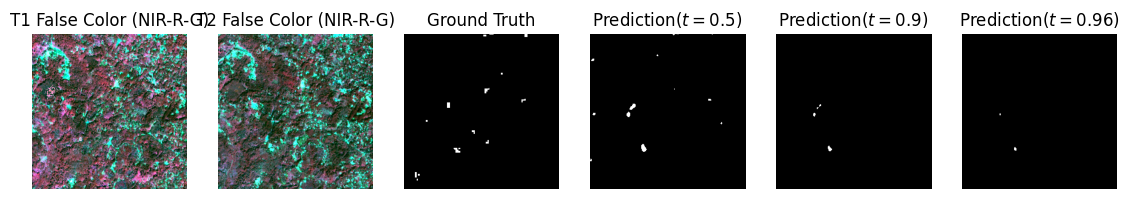

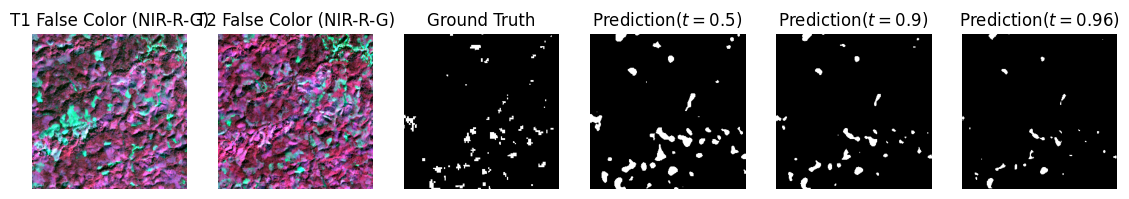

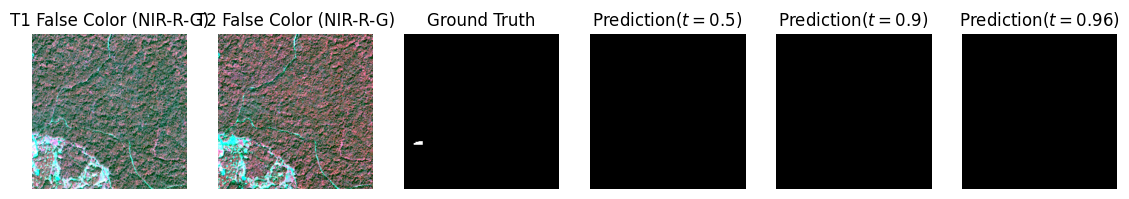

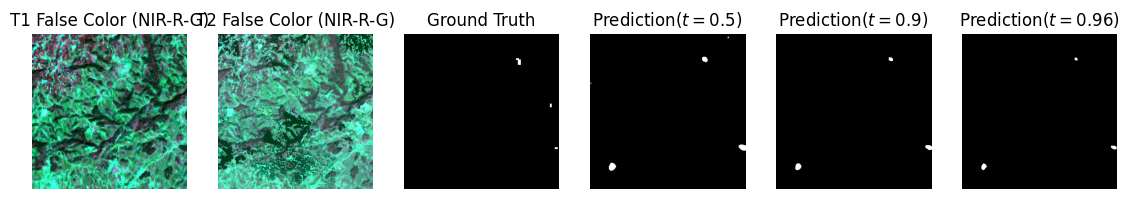

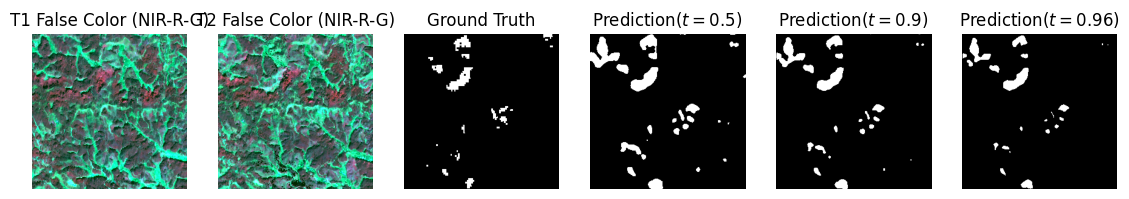

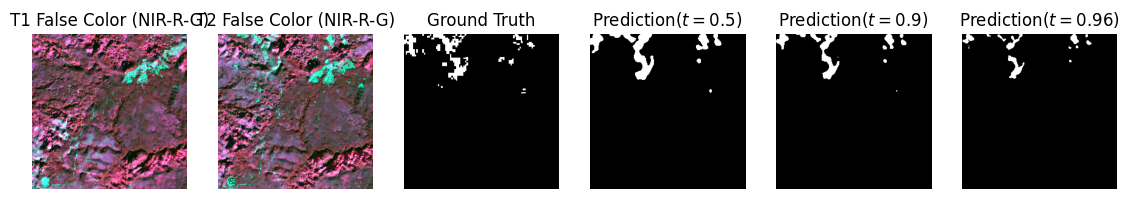

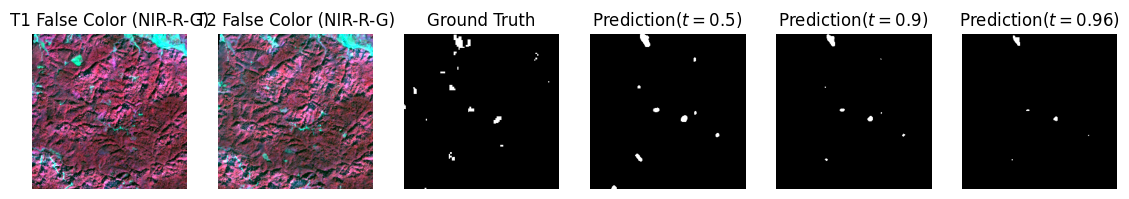

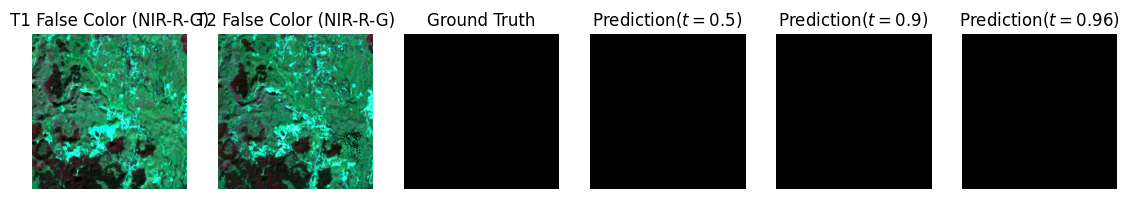

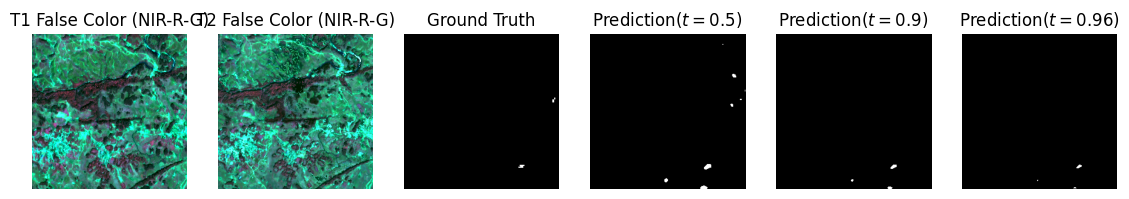

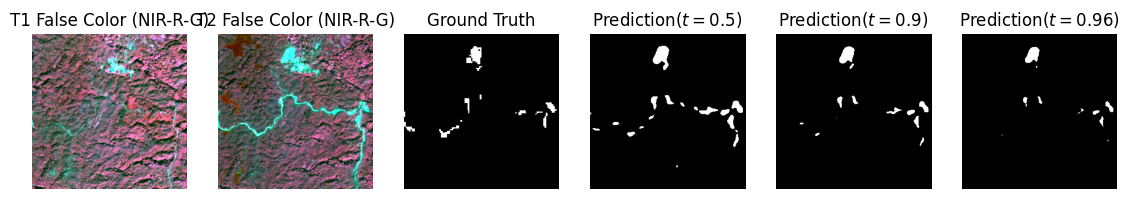

In [48]:
# -----------------------
# Run inference
# -----------------------
num_samples = 8
thresholds = [0.5, 0.9, 0.96]
with torch.no_grad():

    for i, (t1, t2, label) in enumerate(test_loader):

        t1 = t1.to(device)
        t2 = t2.to(device)

        pred = model(t1, t2)

        pred = torch.sigmoid(pred)
        preds = [(pred > t).float()[0, 0] for t in thresholds]

        visualize_sample(
            t1[0],
            t2[0],
            preds,
            label[0].squeeze(),
            NIR=True,
            thresholds=thresholds
        )

        if i >= num_samples + 1:
            break

In [52]:
def evaluate_thresholds(model, dataloader, thresholds, device):

    model.eval()

    results = []

    with torch.no_grad():

        for t in thresholds:

            ious = []

            for t1, t2, label in tqdm(dataloader, desc=f"Threshold {t}"):

                t1 = t1.to(device)
                t2 = t2.to(device)
                label = label.to(device).float()

                pred = model(t1, t2)

                # ---- sigmoid + threshold ----
                pred = torch.sigmoid(pred)
                pred_bin = (pred > t).float()

                # ---- flatten ----
                pred_bin = pred_bin.view(-1)
                label = label.view(-1)

                # ---- IoU ----
                intersection = (pred_bin * label).sum()
                union = pred_bin.sum() + label.sum() - intersection

                iou = (intersection / (union + 1e-6)).item()

                ious.append(iou)

            results.append(np.mean(ious))

    return results

In [55]:
thresholds = np.linspace(0.1, 1.0, 19)  # step = 0.05
ious = evaluate_thresholds(model, test_loader, thresholds, device)

Threshold 1.0: 100%|██████████| 867/867 [00:35<00:00, 24.41it/s]


Best threshold: 0.55
Best IoU: 0.25032651486684115


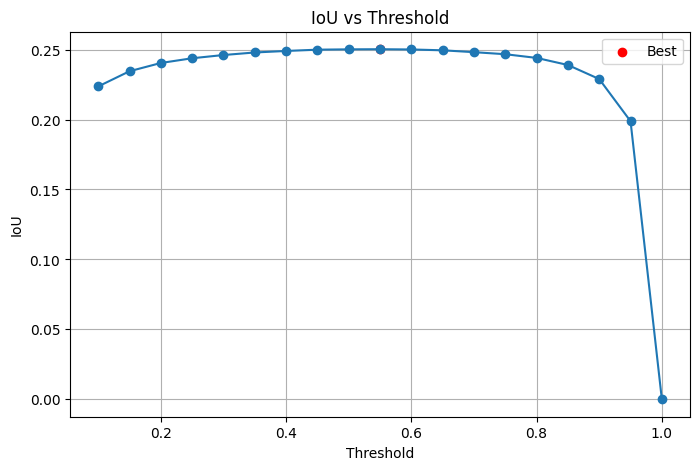

In [56]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, ious, marker='o')

best_idx = np.argmax(ious)

plt.scatter(thresholds[best_idx], ious[best_idx], color='red', label='Best')

plt.xlabel("Threshold")
plt.ylabel("IoU")
plt.title("IoU vs Threshold")
plt.legend()
plt.grid()

print("Best threshold:", thresholds[best_idx])
print("Best IoU:", ious[best_idx])

plt.show()